# W06 · Pink-PEPS & the 1/f story / Pink-PEPS 與 1/f

**English.** Natural images have power spectra that fall off roughly as
`1/f^alpha`. Pink-PEPS follows Algorithm 1 exactly: for latent width `d`,
`a_i=max(1,floor(d/2^i))`, `G_i=sum_{j=0}^i a_j`, and the grouped point order
`(x,S_1..S_L,C_1..C_L)` uses opposite circular slices for sine and cosine.
For `d=8,L=6`, this deterministically changes the aggregation dimension from
104 to 28. That is a structural invariant, not a matched-PSNR or total-parameter
claim; rerun the cells below before reporting empirical savings.

**繁體中文.** 自然影像的功率譜大致以 `1/f^alpha` 衰減。Pink-PEPS 依此把 latent
容量依論文 Algorithm 1 分配:`a_i=max(1,floor(d/2^i))`,以累積 `G_i` 決定
sin/cos 反向的 circular slices,並嚴守 `(x,S_1..S_L,C_1..C_L)` 點順序。
`d=8,L=6` 時聚合維度必然由 104 變為 28;這是結構不變量,不是等 PSNR 或總參數
結論。下列實驗須重跑後才能報告節省幅度。

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import torch, matplotlib.pyplot as plt
from peps.train import auto_device
device = auto_device(); print('device', device)

device cuda


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


## 1. Verify 1/f PSD on Kodak (reproduce Fig. 3) / 驗證 1/f(重現 Fig.3)

estimated 1/f slope alpha = 2.45


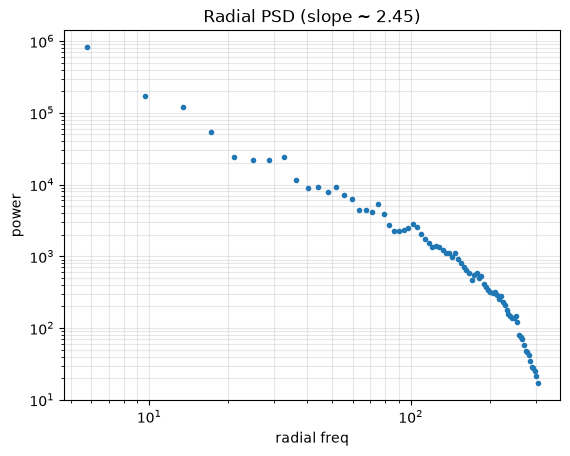

In [2]:
from apps.image.data import load_image, find_kodak
from peps.spectral import radial_psd, fit_one_over_f
import numpy as np
img = load_image(find_kodak(1), max_size=512)
freqs, psd = radial_psd(img, nbins=80)
alpha = fit_one_over_f(freqs, psd)
print(f'estimated 1/f slope alpha = {alpha:.2f}')
plt.loglog(freqs, psd, '.'); plt.xlabel('radial freq'); plt.ylabel('power')
plt.title(f'Radial PSD (slope ~ {alpha:.2f})'); plt.grid(True, which='both', alpha=0.3); plt.show()

## 2. Re-run Pink vs Concat on the same grid / 同一 grid 重跑 Pink vs Concat
Both share the 128x128x8 grid; only the aggregator differs. Measure quality
again after the corrected allocation instead of carrying forward old results.
兩者共用 128x128x8 grid,只差聚合器。修正配置後重新量測,不沿用舊結果。

In [3]:
from apps.image.data import image_to_coords_targets
from apps.image.build import build_grid_peps
from peps.train import fit, TrainConfig, render_full
from peps.metrics import psnr
coords, targets, (H, W) = image_to_coords_targets(img)
def run(agg, res=128, fd=8, steps=2500):
    model, pc = build_grid_peps(resolution=res, feature_dim=fd, num_frequencies=6, aggregator=agg)
    fit(model, coords, targets, TrainConfig(steps=steps, batch_size=32768, lr=1e-2, device=device))
    pred = render_full(model, coords, device=device).reshape(H, W, 3).clamp(0, 1)
    return pc, psnr(pred, img), model.aggregator.out_dim
c_pc, c_ps, c_od = run('concat')
p_pc, p_ps, p_od = run('pink')
print(f'concat: params={c_pc}  agg_out_dim={c_od}  PSNR={c_ps:.2f} dB')
print(f'pink  : params={p_pc}  agg_out_dim={p_od}  PSNR={p_ps:.2f} dB')
print(f'  measured dPSNR={p_ps-c_ps:+.2f} dB; '
      f'aggregation {100*(1-p_od/c_od):.0f}% smaller; total {100*(1-p_pc/c_pc):.0f}% smaller')

concat: params=146307  agg_out_dim=104  PSNR=34.46 dB
pink  : params=141443  agg_out_dim=28  PSNR=35.50 dB
  measured dPSNR=+1.04 dB; aggregation 73% smaller; total 3% smaller


## 3. Recompute the total-parameter frontier / 重算總參數前緣
The shared grid and corrected decoder depth both affect the total budget.
Record the complete rerun rather than inferring total savings from out_dim.
共享 grid 與修正後的 decoder 深度都影響總預算;應記錄完整重跑結果,不可只由
out_dim 推論總參數節省。

In [4]:
import csv, os
rows = [('concat', 128, 8, c_pc, c_od, c_ps), ('pink', 128, 8, p_pc, p_od, p_ps)]
for res in (120, 112):
    pc, ps, od = run('pink', res=res)
    rows.append(('pink', res, 8, pc, od, ps))
print(f"{'agg':7s}{'res':>5s}{'params':>9s}{'agg_od':>8s}{'PSNR':>8s}{'total-':>9s}{'dPSNR':>8s}")
for agg, res, fd, pc, od, ps in rows:
    print(f'{agg:7s}{res:5d}{pc:9d}{od:8d}{ps:8.2f}{100*(1-pc/c_pc):8.0f}%{ps-c_ps:+8.2f}')
os.makedirs('../results', exist_ok=True)
with open('../results/pink_param_savings.csv', 'w', newline='') as f:
    w = csv.writer(f, lineterminator='\n')
    w.writerow(['aggregator','resolution','feature_dim','params','pct_fewer_total','agg_out_dim','pct_fewer_agg','psnr','dpsnr_vs_concat'])
    for agg, res, fd, pc, od, ps in rows:
        w.writerow([agg, res, fd, pc, round(100*(1-pc/c_pc),1), od, round(100*(1-od/c_od),1), round(ps,3), round(ps-c_ps,3)])
print('saved ../results/pink_param_savings.csv')

agg      res   params  agg_od    PSNR   total-   dPSNR
concat   128   146307     104   34.46       0%   +0.00
pink     128   141443      28   35.50       3%   +1.04
pink     120   125571      28   33.86      14%   -0.60
pink     112   110723      28   33.70      24%   -0.76
saved ../results/pink_param_savings.csv


## 4. Takeaway / 小結
The exact allocation and circular slices are now testable invariants. Quality
and total-parameter savings remain empirical outputs of this rerun.

精確配置與 circular slices 現在是可測試的不變量;品質與總參數節省仍須由本次
重跑產生。